# Native RAG vs Two-Call Baseline: Data Analysis

**Authors:** Chelsea Huynh, Darragh Mahns, Chaya Vijayakumar

This notebook collects the main plots selected for the project report.

Included analyses:

1. **Seed neighborhood overlap**: paired scatter plot comparing native RAG vs baseline seed neighborhood redundancy.
2. **Label diversity**: mean unique label count by BFS depth.
3. **Latency**: average measured latency by query segment, grouped by `top_k` and `depth`.


## Setup

Use the project kernel:

`Neo4j RAG Benchmark (.venv)`

If plotting packages are missing, install them into the project venv:

```bash
cd /Users/chelseahuynh/CSCI543-Project-2-Neo4j/neo4j/neo4j-rag-benchmark
source .venv/bin/activate
python -m pip install pandas numpy matplotlib seaborn
```

In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None
    plt.style.use("ggplot")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## Load Benchmark Outputs

This notebook uses the `20260416-144403` run.

Files used:

- `results/comparison_quality-20260416-144403.csv`
- `results/native_rag-20260416-144403.csv`
- `results/two_call_baseline-20260416-144403.csv`

In [ ]:
RUN_ID = "20260416-144403"

# This notebook may be launched from several places depending on whether you open
# Jupyter from the repo root, the benchmark folder, or the results folder. Detect
# the moved neo4j/results directory by looking for this run's quality CSV.
def find_results_dir(run_id):
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "results",
        cwd.parent / "results",
        cwd.parent.parent / "results",
        cwd / "neo4j" / "results",
        cwd.parent / "neo4j" / "results",
    ]

    for candidate in candidates:
        quality_csv = candidate / f"comparison_quality-{run_id}.csv"
        native_csv = candidate / f"native_rag-{run_id}.csv"
        baseline_csv = candidate / f"two_call_baseline-{run_id}.csv"
        if quality_csv.exists() and native_csv.exists() and baseline_csv.exists():
            return candidate

    searched = "\n".join(str(c) for c in candidates)
    raise FileNotFoundError(
        f"Could not find moved results directory for RUN_ID={run_id}. "
        f"Searched:\n{searched}"
    )

RESULTS_DIR = find_results_dir(RUN_ID)
QUALITY_CSV = RESULTS_DIR / f"comparison_quality-{RUN_ID}.csv"
NATIVE_RAW_CSV = RESULTS_DIR / f"native_rag-{RUN_ID}.csv"
BASELINE_RAW_CSV = RESULTS_DIR / f"two_call_baseline-{RUN_ID}.csv"
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

quality_df = pd.read_csv(QUALITY_CSV)
native_raw_df = pd.read_csv(NATIVE_RAW_CSV)
baseline_raw_df = pd.read_csv(BASELINE_RAW_CSV)

print(f"Using results directory: {RESULTS_DIR}")
print(f"Quality rows: {len(quality_df):,} from {QUALITY_CSV.name}")
print(f"Native raw rows: {len(native_raw_df):,} from {NATIVE_RAW_CSV.name}")
print(f"Baseline raw rows: {len(baseline_raw_df):,} from {BASELINE_RAW_CSV.name}")

Quality rows: 6,000 from comparison_quality-20260416-144403.csv
Native raw rows: 6,000 from native_rag-20260416-144403.csv
Baseline raw rows: 6,000 from two_call_baseline-20260416-144403.csv


# Plot 1: Paired Scatter Plot for Seed Neighborhood Overlap

This plot compares the mean pairwise 1-hop neighborhood overlap among selected seed nodes.

Metric:

`mean_pairwise_neighborhood_overlap`

Interpretation:

- Lower overlap means the selected seeds have less redundant local graph context.
- Points below the diagonal mean native RAG had lower neighborhood overlap than the baseline for that query case.
- Points above the diagonal mean the baseline had lower neighborhood overlap.
- Points on the diagonal mean both methods were equal.

Why this matters:

The native RAG reranker was designed to reduce redundant seed neighborhoods. If most points fall below the diagonal, that is evidence that native RAG is changing seed selection in the intended direction: choosing seeds from more distinct graph neighborhoods.

Important caveat:

This is a diversity/redundancy metric, not an accuracy metric. A lower overlap does not automatically mean the retrieved results are more semantically correct. It means the seed set covers less duplicate graph context.

In [3]:
NATIVE_OVERLAP = "native_mean_pairwise_neighborhood_overlap"
BASELINE_OVERLAP = "baseline_mean_pairwise_neighborhood_overlap"

for col in ["top_k", "depth", NATIVE_OVERLAP, BASELINE_OVERLAP]:
    quality_df[col] = pd.to_numeric(quality_df[col], errors="coerce")

overlap_df = quality_df[
    (quality_df["top_k"] > 1)
    & quality_df[NATIVE_OVERLAP].notna()
    & quality_df[BASELINE_OVERLAP].notna()
].copy()

overlap_df["overlap_reduction"] = overlap_df[BASELINE_OVERLAP] - overlap_df[NATIVE_OVERLAP]

overlap_summary = pd.Series({
    "rows": len(overlap_df),
    "native_mean_overlap": overlap_df[NATIVE_OVERLAP].mean(),
    "baseline_mean_overlap": overlap_df[BASELINE_OVERLAP].mean(),
    "mean_overlap_reduction_baseline_minus_native": overlap_df["overlap_reduction"].mean(),
    "median_overlap_reduction_baseline_minus_native": overlap_df["overlap_reduction"].median(),
    "native_lower_fraction": (overlap_df["overlap_reduction"] > 0).mean(),
    "tie_fraction": (overlap_df["overlap_reduction"] == 0).mean(),
    "baseline_lower_fraction": (overlap_df["overlap_reduction"] < 0).mean(),
}).to_frame("value")

overlap_summary

,value
rows,4500.000000
native_mean_overlap,0.000107
baseline_mean_overlap,0.020125
mean_overlap_reduction_baseline_minus_native,0.020019
median_overlap_reduction_baseline_minus_native,0.006046
native_lower_fraction,0.640000
tie_fraction,0.358667
baseline_lower_fraction,0.001333


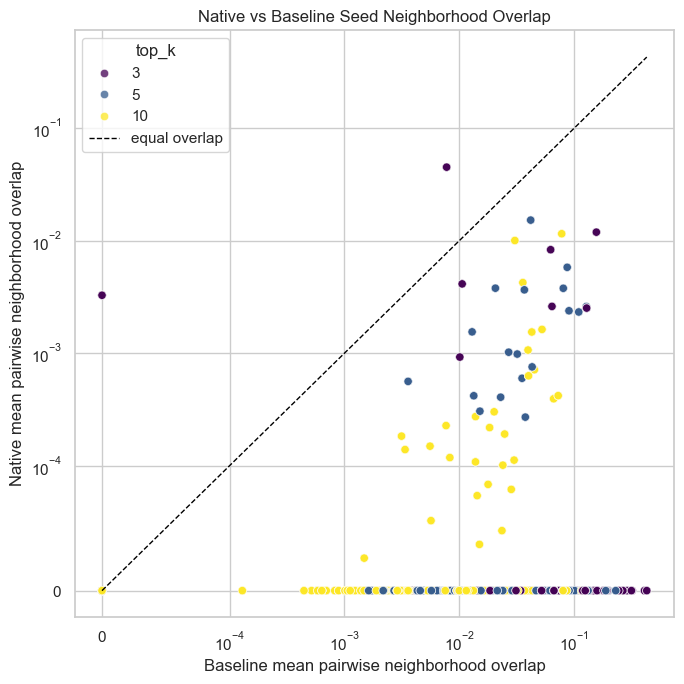

Saved plot to /Users/chelseahuynh/CSCI543-Project-2-Neo4j/neo4j/neo4j-rag-benchmark/results/plots/paired_neighborhood_overlap-20260416-144403.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

if sns:
    sns.scatterplot(
        data=overlap_df,
        x=BASELINE_OVERLAP,
        y=NATIVE_OVERLAP,
        hue="top_k",
        palette="viridis",
        alpha=0.75,
        ax=ax,
    )
else:
    scatter = ax.scatter(
        overlap_df[BASELINE_OVERLAP],
        overlap_df[NATIVE_OVERLAP],
        c=overlap_df["top_k"],
        alpha=0.75,
    )
    fig.colorbar(scatter, ax=ax, label="top_k")

max_val = max(overlap_df[BASELINE_OVERLAP].max(), overlap_df[NATIVE_OVERLAP].max())
ax.plot([0, max_val], [0, max_val], linestyle="--", color="black", linewidth=1, label="equal overlap")

ax.set_title("Native vs Baseline Seed Neighborhood Overlap")
ax.set_xlabel("Baseline mean pairwise neighborhood overlap")
ax.set_ylabel("Native mean pairwise neighborhood overlap")
# Log scale (strict): requires all plotted values > 0
ax.set_xscale("symlog", linthresh=1e-4)
ax.set_yscale("symlog", linthresh=1e-4)
ax.legend(title="top_k", loc="best")
plt.tight_layout()

out_path = PLOTS_DIR / f"paired_neighborhood_overlap-{RUN_ID}.png"
plt.savefig(out_path, dpi=180)
plt.show()
print(f"Saved plot to {out_path}")

# Plot 2: Mean Unique Label Count by BFS Depth

This plot compares final-result label diversity using OGBN-Arxiv paper labels. Each node in the OGBN-Arxiv paper dataset includes an attribute that labels the computer science subcategory that that paper is based upon. This metric measures the number of unique computer science subcategories the method return, in order to get a sense of label diversity.

Metric:

`unique_label_count`

Interpretation:

- Higher unique label count means the final returned result set spans more paper categories.
- Similar counts mean both methods cover similar category breadth.
- Native higher than baseline means native RAG returned broader category coverage.
- Baseline higher than native means the baseline returned broader category coverage.

Why BFS depth matters:

As depth increases, each method expands farther from its selected seeds. Deeper expansion usually returns more nodes and therefore can include more labels/categories. This plot helps show whether native RAG changes category breadth after graph expansion.

Important caveat:

Higher label diversity is not automatically better. Some queries may correctly focus on one category. This metric is best interpreted as topical breadth/coverage, not accuracy.

In [7]:
LABEL_COLS = ["native_unique_label_count", "baseline_unique_label_count"]
for col in ["depth", *LABEL_COLS]:
    quality_df[col] = pd.to_numeric(quality_df[col], errors="coerce")

label_df = quality_df[
    quality_df["native_unique_label_count"].notna()
    & quality_df["baseline_unique_label_count"].notna()
].copy()

label_df["unique_label_count_difference"] = (
    label_df["native_unique_label_count"] - label_df["baseline_unique_label_count"]
)

label_summary = pd.Series({
    "rows": len(label_df),
    "native_mean_unique_label_count": label_df["native_unique_label_count"].mean(),
    "baseline_mean_unique_label_count": label_df["baseline_unique_label_count"].mean(),
    "mean_difference_native_minus_baseline": label_df["unique_label_count_difference"].mean(),
    "median_difference_native_minus_baseline": label_df["unique_label_count_difference"].median(),
    "native_higher_fraction": (label_df["unique_label_count_difference"] > 0).mean(),
    "tie_fraction": (label_df["unique_label_count_difference"] == 0).mean(),
    "baseline_higher_fraction": (label_df["unique_label_count_difference"] < 0).mean(),
}).to_frame("value")

label_summary

,value
rows,6000.000000
native_mean_unique_label_count,12.167667
baseline_mean_unique_label_count,12.233833
mean_difference_native_minus_baseline,-0.066167
median_difference_native_minus_baseline,0.000000
native_higher_fraction,0.384500
tie_fraction,0.306167
baseline_higher_fraction,0.309333


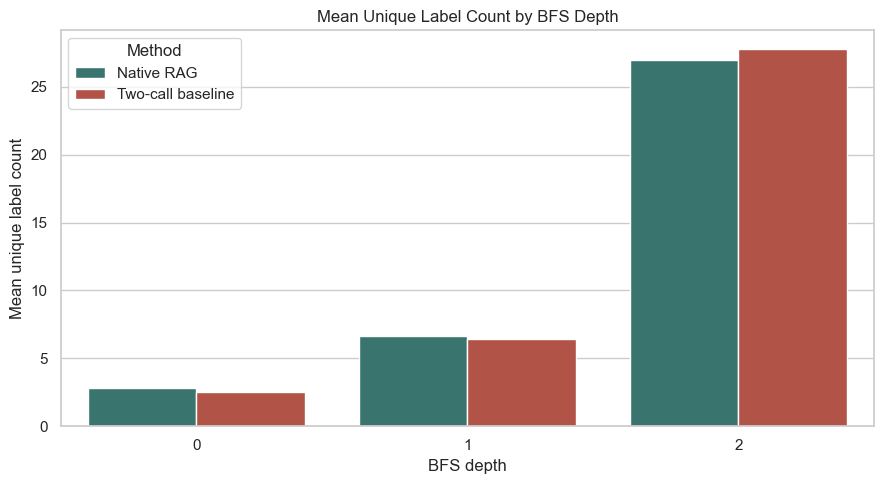

Saved plot to /Users/chelseahuynh/CSCI543-Project-2-Neo4j/neo4j/neo4j-rag-benchmark/results/plots/mean_unique_label_count_by_depth-20260416-144403.png


,depth,cases,native_mean_unique_label_count,baseline_mean_unique_label_count,mean_unique_label_count_difference
0,0,2000,2.821,2.5010,0.3200
1,1,2000,6.672,6.4260,0.2460
2,2,2000,27.010,27.7745,-0.7645


In [8]:
label_by_depth = label_df.groupby("depth", as_index=False).agg(
    cases=("query_id", "count"),
    native_mean_unique_label_count=("native_unique_label_count", "mean"),
    baseline_mean_unique_label_count=("baseline_unique_label_count", "mean"),
    mean_unique_label_count_difference=("unique_label_count_difference", "mean"),
)

plot_label_depth = label_by_depth.melt(
    id_vars=["depth"],
    value_vars=["native_mean_unique_label_count", "baseline_mean_unique_label_count"],
    var_name="method",
    value_name="mean_unique_label_count",
)
plot_label_depth["method"] = plot_label_depth["method"].map({
    "native_mean_unique_label_count": "Native RAG",
    "baseline_mean_unique_label_count": "Two-call baseline",
})

fig, ax = plt.subplots(figsize=(9, 5))

if sns:
    sns.barplot(data=plot_label_depth, x="depth", y="mean_unique_label_count", hue="method", ax=ax, palette=["#2f7f75", "#c44536"])
else:
    pivot = plot_label_depth.pivot(index="depth", columns="method", values="mean_unique_label_count")
    pivot.plot(kind="bar", ax=ax, color=["#2f7f75", "#c44536"])

ax.set_title("Mean Unique Label Count by BFS Depth")
ax.set_xlabel("BFS depth")
ax.set_ylabel("Mean unique label count")
ax.legend(title="Method")
plt.tight_layout()

out_path = PLOTS_DIR / f"mean_unique_label_count_by_depth-{RUN_ID}.png"
plt.savefig(out_path, dpi=180)
plt.show()
print(f"Saved plot to {out_path}")

label_by_depth

# Plot 3: Average Measured Latency by Query Segment

This plot compares native RAG and the two-call baseline using measured benchmark runs only.

Segment definition:

`topk-{K}-depth-{D}`

For each segment, we average `latency_ms` across all measured runs in the corresponding raw CSV.

Interpretation:

- Lower latency is faster.
- Negative delta means native RAG is faster than baseline.
- Positive delta means native RAG is slower than baseline.

Why segmenting matters:

`top_k` and `depth` change query cost. Depth especially matters because deeper BFS expansion can return much larger result sets. Segmenting prevents a single overall average from hiding where native RAG is faster or slower.

In [9]:
SEGMENT_PATTERN = re.compile(r"topk-(\d+)-depth-(\d+)")


def load_segment_means(df):
    measured = df[df["phase"] == "measured"].copy()
    extracted = measured["query_id"].astype(str).str.extract(SEGMENT_PATTERN)
    measured["top_k"] = pd.to_numeric(extracted[0], errors="coerce")
    measured["depth"] = pd.to_numeric(extracted[1], errors="coerce")
    measured["latency_ms"] = pd.to_numeric(measured["latency_ms"], errors="coerce")
    measured = measured.dropna(subset=["top_k", "depth", "latency_ms"])
    measured["top_k"] = measured["top_k"].astype(int)
    measured["depth"] = measured["depth"].astype(int)

    segment_stats = measured.groupby(["top_k", "depth"], as_index=False).agg(
        avg_latency_ms=("latency_ms", "mean"),
        median_latency_ms=("latency_ms", "median"),
        run_count=("latency_ms", "count"),
        p95_latency_ms=("latency_ms", lambda s: s.quantile(0.95)),
    )
    return segment_stats

native_segments = load_segment_means(native_raw_df).rename(columns={
    "avg_latency_ms": "native_avg_ms",
    "median_latency_ms": "native_median_ms",
    "run_count": "native_count",
    "p95_latency_ms": "native_p95_ms",
})

baseline_segments = load_segment_means(baseline_raw_df).rename(columns={
    "avg_latency_ms": "baseline_avg_ms",
    "median_latency_ms": "baseline_median_ms",
    "run_count": "baseline_count",
    "p95_latency_ms": "baseline_p95_ms",
})

segment_stats = native_segments.merge(baseline_segments, on=["top_k", "depth"], how="outer")
segment_stats = segment_stats.sort_values(["top_k", "depth"]).reset_index(drop=True)
segment_stats["segment"] = segment_stats.apply(lambda r: f"topk-{int(r['top_k'])}-d{int(r['depth'])}", axis=1)
segment_stats["delta_ms_native_minus_baseline"] = segment_stats["native_avg_ms"] - segment_stats["baseline_avg_ms"]
segment_stats["delta_pct_vs_baseline"] = segment_stats["delta_ms_native_minus_baseline"] / segment_stats["baseline_avg_ms"] * 100.0
segment_stats["faster_method"] = np.where(
    segment_stats["delta_ms_native_minus_baseline"] < 0,
    "native_rag",
    np.where(segment_stats["delta_ms_native_minus_baseline"] > 0, "two_call_baseline", "tie"),
)

segment_stats[[
    "segment", "native_avg_ms", "baseline_avg_ms", "native_count", "baseline_count",
    "delta_ms_native_minus_baseline", "delta_pct_vs_baseline", "faster_method"
]]

,segment,native_avg_ms,baseline_avg_ms,native_count,baseline_count,delta_ms_native_minus_baseline,delta_pct_vs_baseline,faster_method
0,topk-1-d0,1.074999,1.373355,500,500,-0.298356,-21.724618,native_rag
1,topk-1-d1,1.526463,1.551333,500,500,-0.024870,-1.603162,native_rag
2,topk-1-d2,76.039975,88.473482,500,500,-12.433507,-14.053371,native_rag
3,topk-3-d0,1.469453,1.516806,500,500,-0.047353,-3.121874,native_rag
4,topk-3-d1,2.092193,2.198145,500,500,-0.105952,-4.820083,native_rag
5,topk-3-d2,173.274940,204.309033,500,500,-31.034093,-15.189780,native_rag
6,topk-5-d0,1.930054,1.622502,500,500,0.307552,18.955444,two_call_baseline
7,topk-5-d1,3.011020,2.881966,500,500,0.129055,4.478005,two_call_baseline
8,topk-5-d2,239.998123,232.747657,500,500,7.250466,3.115162,two_call_baseline
9,topk-10-d0,4.587997,1.965972,500,500,2.622024,133.370353,two_call_baseline


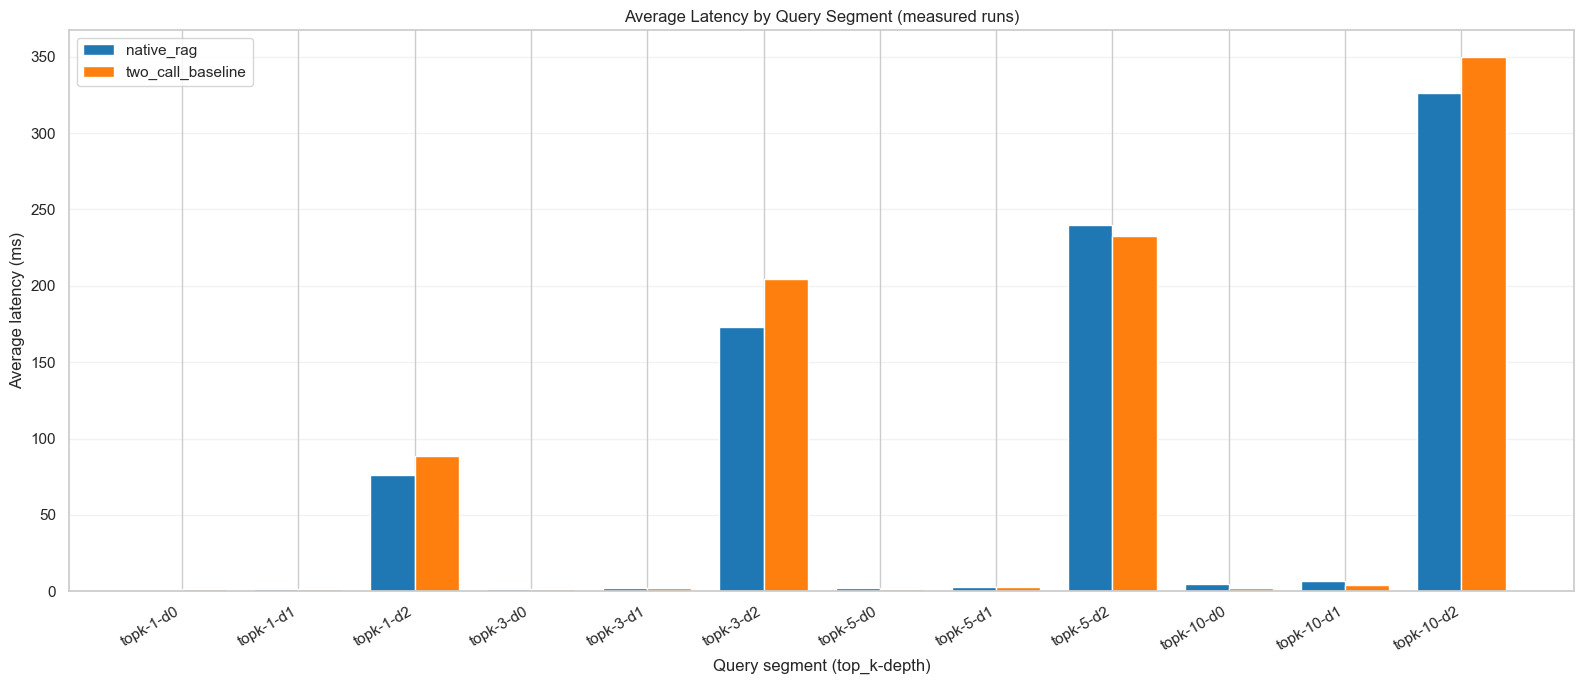

Saved plot to /Users/chelseahuynh/CSCI543-Project-2-Neo4j/neo4j/neo4j-rag-benchmark/results/plots/avg_latency_by_segment-20260416-144403.png


In [10]:
labels = segment_stats["segment"].tolist()
x = np.arange(len(segment_stats))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(x - width / 2, segment_stats["native_avg_ms"], width=width, label="native_rag", color="#1f77b4")
ax.bar(x + width / 2, segment_stats["baseline_avg_ms"], width=width, label="two_call_baseline", color="#ff7f0e")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Average latency (ms)")
ax.set_xlabel("Query segment (top_k-depth)")
ax.set_title("Average Latency by Query Segment (measured runs)")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()

out_path = PLOTS_DIR / f"avg_latency_by_segment-{RUN_ID}.png"
plt.savefig(out_path, dpi=180)
plt.show()
print(f"Saved plot to {out_path}")

In [11]:
overall_native = segment_stats["native_avg_ms"].dropna().mean()
overall_baseline = segment_stats["baseline_avg_ms"].dropna().mean()
overall_delta = overall_native - overall_baseline
overall_delta_pct = overall_delta / overall_baseline * 100.0

latency_summary = pd.Series({
    "segments": len(segment_stats),
    "overall_segment_mean_native_ms": overall_native,
    "overall_segment_mean_baseline_ms": overall_baseline,
    "overall_delta_ms_native_minus_baseline": overall_delta,
    "overall_delta_pct_vs_baseline": overall_delta_pct,
    "native_faster_segment_fraction": (segment_stats["delta_ms_native_minus_baseline"] < 0).mean(),
    "baseline_faster_segment_fraction": (segment_stats["delta_ms_native_minus_baseline"] > 0).mean(),
}).to_frame("value")

latency_summary

,value
segments,12.000000
overall_segment_mean_native_ms,69.832602
overall_segment_mean_baseline_ms,74.388458
overall_delta_ms_native_minus_baseline,-4.555857
overall_delta_pct_vs_baseline,-6.124414
native_faster_segment_fraction,0.583333
baseline_faster_segment_fraction,0.416667
